# Занятие 22. Практика: классификация иконок методом k ближайших соседей (kNN)

Вы **пишете код сами** в пустых ячейках. Блоки **«Легенда»** и **«Дано»** не меняйте.

Теория — в `Урок_21_Workflow_kNN.ipynb`.


---
## Легенда: студия «Pixel Quest»

Вы — стажёр в инди-студии, которая выпускает пошаговую стратегию **«Pixel Quest»**.
Игрок расставляет на карте **юниты** — крошечные чёрно-белые фигурки размером **10×10 пикселей**.

### Три типа юнитов

| Класс | По-русски | Роль в игре |
|-------|-----------|-------------|
| `castle` | замок | защита базы, «тяжёлая» фигура |
| `dragon` | дракон | летающий атакующий юнит |
| `knight` | рыцарь | пеший боец |

Игроки рисуют свои варианты иконок и присылают в студию. Художники и геймдизайнеры
отобрали **229** удачных рисунков и сохранили в `approved.json`.
Поле `initial` — правильный тип юнита.

### Зачем нужен этот датасет

Это **эталонная коллекция**: на ней мы учим модель понимать, «похожа» новая иконка на замок, дракона или рыцаря.

### Зачем задача классификации

Когда приходит **новый** рисунок, игра должна **автоматически** подсказать тип и поставить иконку
на нужную кнопку в интерфейсе. Если модель перепутает дракона с рыцарем — игрок увидит не ту фигурку,
а это ломает тактику и доверие к игре.

Ваша цель на занятии — пройти полный путь ML-разработки и обучить **kNN**,
который по 100 пикселям угадывает класс юнита.

### Короткий словарь

| Слово | Значение |
|-------|----------|
| **признак** | одно число про иконку (здесь: один пиксель 0 или 1) |
| **метка / класс** | правильный ответ: `castle`, `dragon`, `knight` |
| **train** | обучающая выборка — на ней модель **учится** |
| **validation** | проверочная — на ней **сравниваем** варианты (например, разные `k`) |
| **test** | отложенная — **финальный экзамен** (один раз в конце) |
| **baseline** | наивная модель «для сравнения» |
| **accuracy** | доля верных ответов |


---
## Дано: датасет и картинки

Каждая иконка — матрица 10×10. В таблице `X_all` она записана **строкой из 100 чисел**
(столбцы `p0` … `p99`). В `y_all` — метка класса.

### Как выглядят иконки разных классов

![Примеры трёх классов](practice_images/samples_by_class.png)

По одному крупному примеру:

| Замок | Дракон | Рыцарь |
|-------|--------|--------|
| ![castle](practice_images/sample_castle.png) | ![dragon](practice_images/sample_dragon.png) | ![knight](practice_images/sample_knight.png) |

### Весь датасет целиком

![Обзор датасета](practice_images/dataset_overview.png)

![Датасет по классам](practice_images/dataset_by_class.png)

### Справочные диаграммы (по всему датасету)

Их **не нужно** перерисовывать в заданиях — это ориентир. В заданиях 3–4 вы построите похожие графики **только по train**.

![Число иконок по классам](practice_images/chart_class_counts.png)
![Плотность пикселей по классам](practice_images/chart_density_boxplot.png)
![Нижний ряд пикселей](practice_images/chart_bottom_row.png)

Запустите ячейку ниже, чтобы загрузить данные в `X_all` и `y_all`.


In [69]:
import json
from pathlib import Path

import numpy as np
import pandas as pd

DATA_PATH = Path('approved.json')
items = json.loads(DATA_PATH.read_text(encoding='utf-8'))

rows, labels = [], []
for item in items:
    matrix = np.array(item['data']['pixels'], dtype=int)
    rows.append(matrix.flatten())
    labels.append(item['data']['initial'])

X_all = pd.DataFrame(rows, columns=[f'p{i}' for i in range(100)])
y_all = pd.Series(labels, name='label')

print('Объектов:', X_all.shape[0], '| признаков:', X_all.shape[1])
print('Классы:')
print(y_all.value_counts())
X_all.iloc[:, :8].head()


Объектов: 229 | признаков: 100
Классы:
label
castle    96
knight    71
dragon    62
Name: count, dtype: int64


,p0,p1,p2,p3,p4,p5,p6,p7
0,0,0,0,0,0,0,0,0
1,0,1,0,0,1,1,1,0
2,0,0,0,0,0,0,0,0
3,0,0,0,0,1,1,0,0
4,1,1,0,0,0,0,0,0


---
## Задание 1. Мини-симуляция релиза иконок

Представьте, что в игру пришла новая иконка. Нужно решить:
- показать её автоматически;
- или отправить художнику на ручную проверку.

В этом задании модель ещё не обучена, поэтому `model_confidence` — **условная уверенность прототипа**, которую вы задаёте сами числами от 0 до 1. Это маленькая разминка про постановку задачи и правила принятия решения.

### Что сделать

**Шаг 1.** Создайте `release_rule` с ключами:
`auto_accept_threshold`, `auto_action`, `manual_action`.

**Шаг 2.** Создайте `incoming_icons` (4 строки) с колонками:
`icon_id`, `predicted_class`, `model_confidence`.

**Шаг 3.** Добавьте `decision` по порогу уверенности:
- если `model_confidence >= auto_accept_threshold`, иконка проходит автоматически;
- иначе иконка уходит на ручную проверку.

**Шаг 4.** Задайте `PRIMARY_METRIC = 'accuracy'` и в markdown объясните, зачем нужна ручная проверка для неуверенных иконок.


In [70]:
def release_rule(model_confidence: float, auto_accept_threshhold: float = 0.7, auto_action: str = 'accept', manual_action: str = 'manual check'):
    print(model_confidence)
    if model_confidence < auto_accept_threshhold:
        return manual_action
    else:
        return auto_action
    
incoming_icons = pd.DataFrame(data={'icon_id': [1, 2, 3, 4], 'predicted_class': ['castle', 'dragon', 'castle', 'knight'], 'model_confidence': [0.2, 0.5, 0.8, 0.9]})

decision = [release_rule(i) for i in incoming_icons['model_confidence']]

print(decision)

PRIMARY_METRIC = 'accuracy'

0.2
0.5
0.8
0.9
['manual check', 'manual check', 'accept', 'accept']


*Почему нужна ручная проверка?*

(напишите здесь)


---
## Задание 2. Импорты и разбиение данных

### Что сделать

**Шаг 1.** Подключите импорты: `train_test_split`, `StandardScaler`, `KNeighborsClassifier`, `DummyClassifier`, `accuracy_score`, `recall_score`, `confusion_matrix`, `matplotlib.pyplot as plt`.

**Шаг 2.** Задайте константы:
- `RANDOM_STATE = 42`
- `TEST_SIZE = 0.2`
- `VAL_SIZE = 0.25`

**Шаг 3.** Сделайте первый split: отделите test от `X_all, y_all`.

**Шаг 4.** Сделайте второй split: из train_val выделите validation.

**Шаг 5.** Выведите размеры train/validation/test.


In [71]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix
import matplotlib.pyplot as plt

RANDOM_STATE = 42
TEST_SIZE = 0.2
VAL_SIZE = 0.25

X_train_val, X_test, y_train_val, y_test = train_test_split(X_all, y_all, random_state=RANDOM_STATE, test_size=TEST_SIZE, stratify=y_all)
X_train, X_val, y_train,  y_val = train_test_split(X_train_val, y_train_val, random_state=RANDOM_STATE, test_size=VAL_SIZE, stratify=y_train_val)

print(y_train.size, 
      y_val.size, 
      y_test.size)

137 46 46


### Шаг 2. Код разбиения train / validation / test


---
## Задание 3. Осмотр train (числа)

### Что сделать

**Шаг 1.** Выведите распределение классов: `y_train.value_counts()`.

**Шаг 2.** Создайте `train_df` и добавьте колонку `label`.

**Шаг 3.** Посчитайте `pixel_density = сумма 100 пикселей / 100`.

**Шаг 4.** Выведите среднюю `pixel_density` по классам.


In [72]:
# 1
print(y_train.value_counts())

# 2
train_df = X_train.copy()
train_df["label"]=y_train

# 3
train_df["pixel_density"] = X_train.sum(axis=1) / 100


# 4
print(train_df.groupby("label")["pixel_density"].mean())
print(train_df["pixel_density"])

label
castle    57
knight    43
dragon    37
Name: count, dtype: int64
label
castle    0.590351
dragon    0.377568
knight    0.365349
Name: pixel_density, dtype: float64
47     0.83
209    0.46
136    0.44
87     0.34
211    0.51
       ... 
74     0.25
152    0.27
186    0.38
35     0.34
118    0.42
Name: pixel_density, Length: 137, dtype: float64


---
## Задание 4. Диаграммы по train

### Что сделать

Постройте 3 графика по train:

**Шаг 1.** Bar: число объектов каждого класса.

**Шаг 2.** Bar: средняя `pixel_density` по классам.

**Шаг 3.** Boxplot: распределение `pixel_density` по классам.

У каждого графика должны быть `title`, `xlabel`, `ylabel`, `plt.show()`.


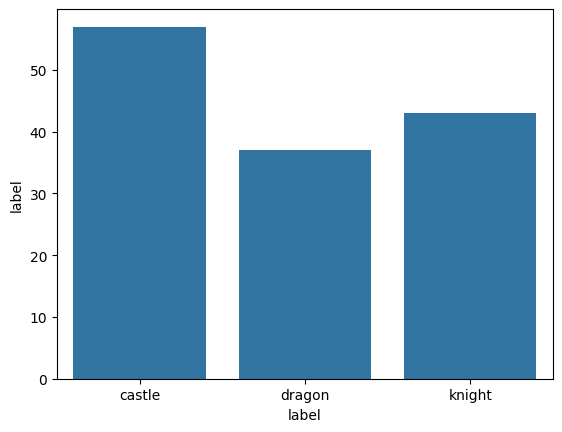

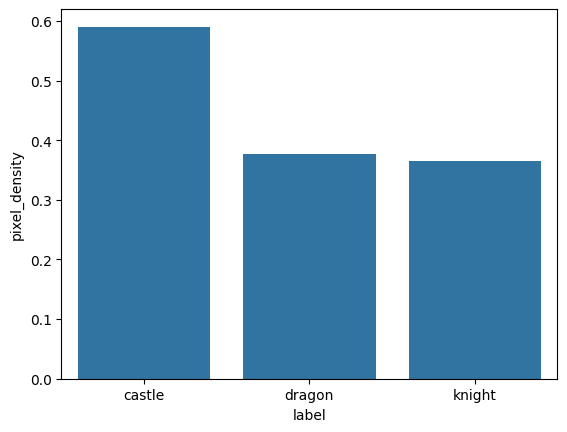

{'whiskers': [<matplotlib.lines.Line2D at 0x1d891de1400>,
 'caps': [<matplotlib.lines.Line2D at 0x1d891de1940>,
 'boxes': [<matplotlib.lines.Line2D at 0x1d891de23c0>,
 'medians': [<matplotlib.lines.Line2D at 0x1d891de1be0>,
 'fliers': [<matplotlib.lines.Line2D at 0x1d891de1a90>,
 'means': []}

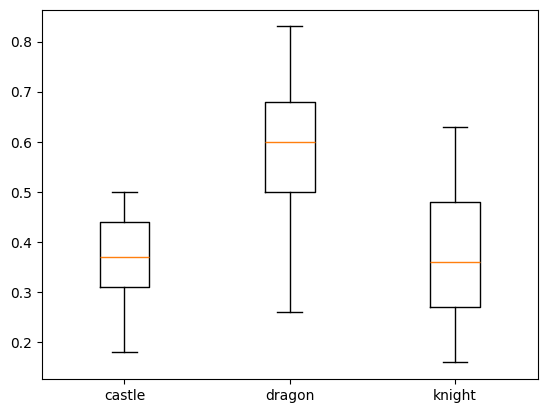

In [73]:
from seaborn import barplot, boxplot

barplot(train_df.groupby("label")["label"].count())
plt.show()

barplot(train_df.groupby("label")["pixel_density"].mean())
plt.show()


data = [train_df[train_df.label==c]["pixel_density"] for c in ['knight', 'castle', 'dragon']]
plt.boxplot(data, tick_labels=['castle','dragon','knight'])

---
## Задание 5. Baseline

### Что сделать

**Шаг 1.** Обучите `DummyClassifier(strategy='most_frequent')` на train.

**Шаг 2.** Посчитайте `dummy_acc` на validation.

**Шаг 3.** Найдите самый частый класс в train и его долю.

**Шаг 4.** Сравните `dummy_acc` с долей самого частого класса. Они должны быть близки по смыслу: baseline всегда выбирает самый частый класс.


In [74]:
model = DummyClassifier(strategy="most_frequent")
model.fit(X_train, y_train)
predict = model.predict(X_train)
dummy_acc = accuracy_score(y_train, predict)
print(dummy_acc, train_df[train_df['label']=='castle'].count()/train_df.count())

0.41605839416058393 p0               0.416058
p1               0.416058
p2               0.416058
p3               0.416058
p4               0.416058
                   ...   
p97              0.416058
p98              0.416058
p99              0.416058
label            0.416058
pixel_density    0.416058
Length: 102, dtype: float64


---
## Задание 6. kNN и сравнение с baseline

### Что сделать

**Шаг 1.** Обучите `KNeighborsClassifier(n_neighbors=5)` на `X_train`, `y_train`.

**Шаг 2.** Посчитайте `acc_raw` на validation.

**Шаг 3.** Постройте bar-диаграмму `dummy_acc` vs `acc_raw`.

**Шаг 4.** Проверьте, что `acc_raw > dummy_acc`.


0.41605839416058393 0.8695652173913043


<Axes: >

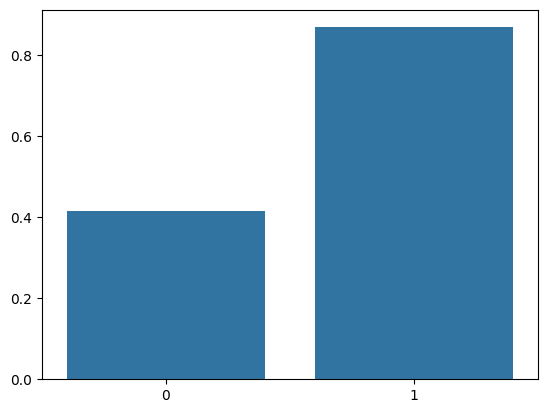

In [75]:
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train, y_train)
predict_knn_y = knn.predict(X_val)
acc_raw = accuracy_score(y_val, predict_knn_y)
print(dummy_acc, acc_raw)
barplot([dummy_acc, acc_raw])

---
## Задание 7. Масштабирование и kNN

### Что сделать

**Шаг 1.** `scaler = StandardScaler()`.

**Шаг 2.** `scaler.fit(X_train)`.

**Шаг 3.** Получите `X_train_s`, `X_val_s`, `X_test_s` через `transform`.

**Шаг 4.** Обучите kNN (`n_neighbors=5`) на `X_train_s`.

**Шаг 5.** Посчитайте `acc_scaled` на validation.

**Шаг 6.** Постройте bar `acc_raw` vs `acc_scaled` и дайте краткий вывод в markdown.


0.41605839416058393 0.8695652173913043 0.8043478260869565


<Axes: >

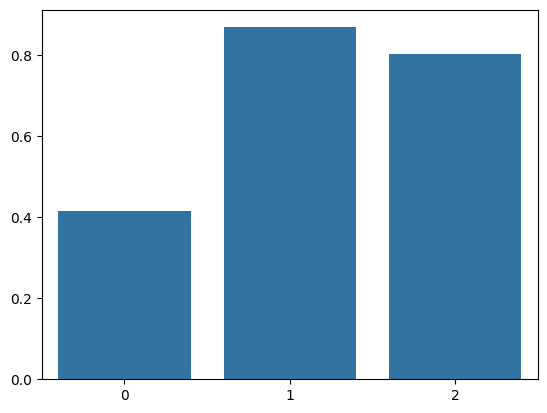

In [76]:
scaler=StandardScaler()
scaler.fit(X_train)
X_train_s = scaler.transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

knn_s = KNeighborsClassifier(n_neighbors=5)
knn_s.fit(X_train_s, y_train)
predict_knn_s = knn_s.predict(X_val_s)
acc_raw_s = accuracy_score(y_val, predict_knn_s)
print(dummy_acc, acc_raw, acc_raw_s)
barplot([dummy_acc, acc_raw, acc_raw_s])

*Вывод про масштабирование:*

(напишите здесь)


---
## Задание 8. Подбор `k` и график

### Что сделать

**Шаг 1.** Сначала посчитайте accuracy для `k=3` как проверочный пример: так вы убедитесь, что обучение kNN на масштабированных данных работает.

**Шаг 2.** Переберите `k` из `[1, 3, 5, 7, 11, 15, 21]`.

**Шаг 3.** Соберите таблицу `k_results` (`k`, `val_acc`).

**Шаг 4.** Найдите `best_k` по validation accuracy.

**Шаг 5.** Постройте линейный график `k`→`val_acc` и отметьте `best_k`.


0.8478260869565217
0.8260869565217391
0.8043478260869565
0.8913043478260869
0.8478260869565217
0.8043478260869565
0.8043478260869565
3
[7, 0.8913043478260869]


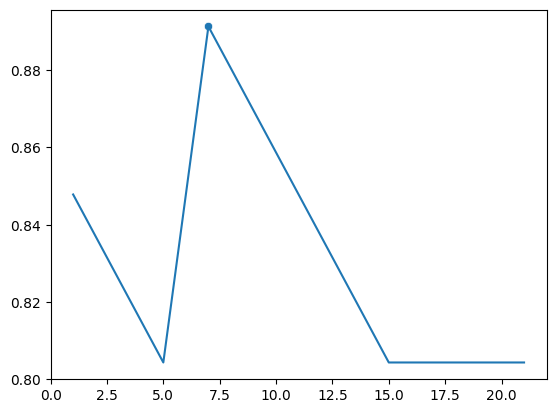

In [77]:
from seaborn import lineplot, scatterplot
k_results = [[],[]]
for k in [1, 3, 5, 7, 11, 15, 21]:
    knn_s = KNeighborsClassifier(k)
    knn_s.fit(X_train_s, y_train)
    predict_knn_s= knn_s.predict(X_val_s)
    acc_raw_s = accuracy_score(y_val, predict_knn_s)
    k_results[0].append(k)
    k_results[1].append(acc_raw_s)
    print(acc_raw_s)
i = np.argmax(k_results[1])
best_k=k_results[0][i]
print(i)
scatterplot(x=[k_results[0][i]],y=[k_results[1][i]], markers="o")
lineplot(x=k_results[0], y=k_results[1])
print([k_results[0][i],k_results[1][i]])


---
## Задание 9. Анализ ошибок и диаграммы

Это большое задание, поэтому делайте его по частям.

### Шаг 9A. Какие классы модель путает?

**Шаг 1.** Обучите kNN с `best_k` на `X_train_s`, получите `y_pred` на validation.

**Шаг 2.** Посчитайте `confusion_matrix` с фиксированным порядком классов:
`['castle', 'dragon', 'knight']`.

**Шаг 3.** Постройте тепловую карту матрицы ошибок.

**Шаг 4.** Посчитайте recall по классам (`average=None`) и отдельно `recall_dragon`.

### Шаг 9B. На каких иконках ошибок больше?

**Шаг 5.** Разделите validation на группы «разреженные/плотные» по медиане `pixel_density`.

**Шаг 6.** Посчитайте долю ошибок в каждой группе и постройте график.

**Шаг 7.** В markdown дайте 2 вывода:
1. какая путаница классов чаще всего видна в матрице ошибок;
2. в какой группе плотности ошибок больше.


In [78]:
def release_rule(model_confidence: float, auto_accept_threshhold: float = 0.7, auto_action: str = 'accept', manual_action: str = 'manual check'):
    print(model_confidence)
    if model_confidence < auto_accept_threshhold:
        return manual_action
    else:
        return auto_action
    
incoming_icons = pd.DataFrame(data={'icon_id': [1, 2, 3, 4], 'predicted_class': ['castle', 'dragon', 'castle', 'knight'], 'model_confidence': [0.2, 0.5, 0.8, 0.9]})

decision = [release_rule(i) for i in incoming_icons['model_confidence']]

print(decision)

PRIMARY_METRIC = 'accuracy'

0.2
0.5
0.8
0.9
['manual check', 'manual check', 'accept', 'accept']


[[13  1  0]
 [ 0  9  3]
 [ 1  0 19]]
[0.95       0.75       0.92857143]
[0.75]


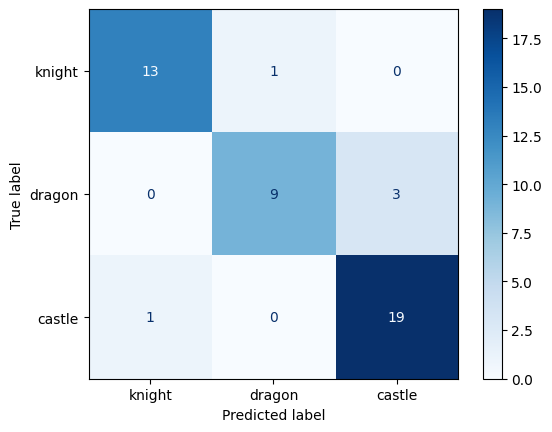

In [79]:
from seaborn import heatmap
from sklearn.metrics import confusion_matrix

knn_best = KNeighborsClassifier(best_k)
knn_best.fit(X_train_s, y_train)
y_pred = knn_best.predict(X_val_s)
cm = confusion_matrix(y_val, y_pred, labels=['knight', 'dragon', 'castle'])
print(cm)    

from sklearn.metrics import ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['knight', 'dragon', 'castle'])
disp.plot(cmap=plt.cm.Blues)

print(recall_score(y_val, y_pred, average=None))
print(recall_score(y_val, y_pred, labels=["dragon"], average=None))

*Выводы по ошибкам:*

(напишите здесь)


---
## Задание 10. Финальная проверка на test

### Что сделать

**Шаг 1.** Посчитайте `test_acc` на `X_test_s` после выбора `best_k`.

**Шаг 2.** Для первой тестовой иконки получите `pred_new` после `scaler.transform(...)`.

**Шаг 3.** Сравните `pred_new` с истинной меткой `y_test.iloc[0]`.


In [82]:
y_pred = knn_best.predict(X_test_s)
test_acc = accuracy_score(y_test, y_pred)
print(test_acc)
pred_new=y_pred[0]
print(pred_new, "-",y_test.iloc[0])

0.7608695652173914
castle - dragon


---
## Итог

Вы прошли путь от легенды и картинок до модели, которая помогает студии «Pixel Quest»
распознавать тип новой иконки.
